<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_RNA/blob/main/RNA_trabalho04_sentiment_analysis_IMDB_pipeline_Sergio_Costa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 04 — Análise de Sentimento com Hugging Face Pipeline

Aluno: Sérgio Henrique Cerqueira Costa - 20251MPCA0080

Disciplina: Redes Neurais Artificiais

Professor: Francisco Boldt

## Objetivo

Usar a classe `pipeline` da biblioteca `transformers`, do Hugging Face, para analisar o sentimento de resenhas da base **IMDB**.

A proposta deste notebook é manter o trabalho simples e alinhado ao enunciado: baixar/carregar a base IMDB, aplicar um pipeline de classificação de sentimentos e comparar as predições com os rótulos reais das resenhas.

## 1. Instalação das bibliotecas

Execute a célula abaixo se o ambiente ainda não tiver as bibliotecas necessárias.

No Google Colab, normalmente será necessário instalar `transformers`. Em ambientes locais, a instalação pode ser dispensada caso as bibliotecas já estejam disponíveis.

In [ ]:
# Execute esta célula somente se necessário.
# No Google Colab, normalmente ela pode ser executada sem problemas.

!pip -q install transformers torch scikit-learn pandas matplotlib tqdm

## 2. Imports e parâmetros gerais

Para manter o tempo de execução controlado, o notebook usa uma amostra balanceada da base de teste da IMDB.

Caso queira avaliar todo o conjunto de teste, altere `RUN_FULL_TEST_SET` para `True`. Essa execução pode demorar bastante em CPU.

In [ ]:
import os
import tarfile
import urllib.request
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

from tqdm.auto import tqdm

In [ ]:
# Reprodutibilidade da amostragem
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Base IMDB indicada no enunciado
DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
DATA_DIR = Path("data_imdb")
TGZ_PATH = DATA_DIR / "aclImdb_v1.tar.gz"
IMDB_DIR = DATA_DIR / "aclImdb"

# Divisão a ser avaliada: "test" evita misturar avaliação com treino.
SPLIT = "test"

# Para execução rápida e reprodutível:
RUN_FULL_TEST_SET = False
N_SAMPLES_PER_CLASS = 100  # 100 positivas + 100 negativas = 200 resenhas

# Modelo usado no notebook da aula para classificação de sentimento na IMDB.
# Alternativa genérica do curso Hugging Face:
# CHECKPOINT = "distilbert-base-uncased-finetuned-sst-2-english"
CHECKPOINT = "lvwerra/distilbert-imdb"

BATCH_SIZE = 16
MAX_LENGTH = 512

DEVICE_ID = 0 if torch.cuda.is_available() else -1
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Modelo:", CHECKPOINT)
print("Dispositivo:", "GPU" if DEVICE_ID == 0 else "CPU")

Modelo: lvwerra/distilbert-imdb
Dispositivo: CPU


## 3. Download e extração da base IMDB

A base `aclImdb_v1.tar.gz` contém resenhas organizadas por diretórios. Para este trabalho, serão usados os diretórios `test/pos` e `test/neg`.

In [ ]:
def safe_extract_tar(tar: tarfile.TarFile, path: Path) -> None:
    """Extrai um arquivo .tar.gz evitando path traversal."""
    path = path.resolve()
    for member in tar.getmembers():
        member_path = (path / member.name).resolve()
        if not str(member_path).startswith(str(path)):
            raise RuntimeError(f"Caminho inseguro no tar: {member.name}")
    tar.extractall(path)


DATA_DIR.mkdir(parents=True, exist_ok=True)

if not TGZ_PATH.exists():
    print("Baixando base IMDB...")
    urllib.request.urlretrieve(DATA_URL, TGZ_PATH)
    print("Download concluído:", TGZ_PATH)
else:
    print("Arquivo compactado já existe:", TGZ_PATH)

if not IMDB_DIR.exists():
    print("Extraindo base IMDB...")
    with tarfile.open(TGZ_PATH, "r:gz") as tar:
        safe_extract_tar(tar, DATA_DIR)
    print("Extração concluída:", IMDB_DIR)
else:
    print("Base já extraída:", IMDB_DIR)

Baixando base IMDB...
Download concluído: data_imdb/aclImdb_v1.tar.gz
Extraindo base IMDB...


/tmp/ipykernel_1579/334943144.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path)


Extração concluída: data_imdb/aclImdb


## 4. Leitura das resenhas e montagem do DataFrame

Os rótulos reais são inferidos pelos diretórios:

- `pos` → `POSITIVE`
- `neg` → `NEGATIVE`

In [ ]:
def read_reviews_from_dir(folder: Path, label: str) -> pd.DataFrame:
    rows = []
    for file_path in sorted(folder.glob("*.txt")):
        text = file_path.read_text(encoding="utf-8", errors="replace")
        rows.append({
            "file": file_path.name,
            "true_label": label,
            "text": text,
            "n_chars": len(text),
        })
    return pd.DataFrame(rows)


pos_dir = IMDB_DIR / SPLIT / "pos"
neg_dir = IMDB_DIR / SPLIT / "neg"

df_pos = read_reviews_from_dir(pos_dir, "POSITIVE")
df_neg = read_reviews_from_dir(neg_dir, "NEGATIVE")

df_all = pd.concat([df_pos, df_neg], ignore_index=True)

print("Total de resenhas carregadas:", len(df_all))
display(df_all.groupby("true_label").size().rename("quantidade").to_frame())
display(df_all.head())

Total de resenhas carregadas: 25000


,quantidade
true_label,
NEGATIVE,12500
POSITIVE,12500


,file,true_label,text,n_chars
0,0_10.txt,POSITIVE,I went and saw this movie last night after bei...,794
1,10000_7.txt,POSITIVE,Actor turned director Bill Paxton follows up h...,2004
2,10001_9.txt,POSITIVE,As a recreational golfer with some knowledge o...,1434
3,10002_8.txt,POSITIVE,"I saw this film in a sneak preview, and it is ...",682
4,10003_8.txt,POSITIVE,Bill Paxton has taken the true story of the 19...,1216


## 5. Amostragem balanceada

A amostra balanceada evita que uma classe tenha mais peso que a outra no cálculo da acurácia.

A execução completa da base de teste também é possível, mas tende a ser mais lenta quando feita apenas com CPU.

In [ ]:
if RUN_FULL_TEST_SET:
    df_eval = df_all.sample(frac=1, random_state=SEED).reset_index(drop=True)
else:
    df_eval = (
        df_all
        .groupby("true_label", group_keys=False)
        .sample(n=N_SAMPLES_PER_CLASS, random_state=SEED)
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )

print("Total de resenhas avaliadas:", len(df_eval))
display(df_eval.groupby("true_label").size().rename("quantidade").to_frame())

# Exemplo de resenha
i = 0
print("Rótulo real:", df_eval.loc[i, "true_label"])
print("Arquivo:", df_eval.loc[i, "file"])
print()
print(df_eval.loc[i, "text"][:1000])

Total de resenhas avaliadas: 200


,quantidade
true_label,
NEGATIVE,100
POSITIVE,100


Rótulo real: NEGATIVE
Arquivo: 44_4.txt

A rather lame teen slasher from Brisbane. While the plot hinges on a fairly decent idea, the writing is profoundly lame and two of the three main teens are absurdly wooden. The problem is that for the kids to go through with their plan they have to be far more reckless than shown, but if they were that devil-may-care, it would perhaps be hard for them to be likable, so they end up being neither really. In fact, I only started enjoying the film when I started wishing for their death. One of those movies where in about a thousand places the most sensible option would be to call the police. I realise we wouldn't have a movie if they did, but it would be nice if we could believe that they actually wouldn't. Avoid.


## 6. Criação do pipeline de análise de sentimento

O `pipeline` agrupa as etapas essenciais:

1. pré-processamento do texto com tokenizer;
2. passagem dos dados pelo modelo Transformer;
3. pós-processamento, convertendo a saída em rótulo e escore.

In [ ]:
classifier = pipeline(
    task="text-classification",
    model=CHECKPOINT,
    tokenizer=CHECKPOINT,
    device=DEVICE_ID,
)

# Teste rápido do pipeline
examples = [
    "This is a great movie.",
    "This is a bad movie.",
]

classifier(examples, truncation=True, max_length=MAX_LENGTH)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9955680966377258},
 {'label': 'NEGATIVE', 'score': 0.9947035908699036}]

## 7. Aplicação do pipeline à amostra da IMDB

A inferência é feita em lotes para reduzir o tempo de processamento.

In [ ]:
def predict_in_batches(texts, batch_size=16):
    predictions = []
    start = time.time()

    for start_idx in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[start_idx:start_idx + batch_size]
        batch_outputs = classifier(
            batch_texts,
            truncation=True,
            max_length=MAX_LENGTH,
            batch_size=batch_size,
        )
        predictions.extend(batch_outputs)

    elapsed = time.time() - start
    print(f"Tempo total de inferência: {elapsed:.2f} s")
    return predictions


texts = df_eval["text"].tolist()
outputs = predict_in_batches(texts, batch_size=BATCH_SIZE)

def normalize_label(raw_label):
    """Mapeia o rótulo retornado pelo modelo para o espaço canônico NEGATIVE/POSITIVE.

    Protege a avaliação contra variações de rótulo como 'pos'/'neg' ou
    'LABEL_0'/'LABEL_1', que diferentes checkpoints (inclusive versões do
    distilbert-imdb) já utilizaram. Sem essa normalização, a comparação direta
    de strings poderia zerar a acurácia mesmo com o modelo acertando.
    """
    key = str(raw_label).strip().upper()
    mapping = {
        "POSITIVE": "POSITIVE", "POS": "POSITIVE", "LABEL_1": "POSITIVE", "1": "POSITIVE",
        "NEGATIVE": "NEGATIVE", "NEG": "NEGATIVE", "LABEL_0": "NEGATIVE", "0": "NEGATIVE",
    }
    return mapping.get(key, key)


df_results = df_eval.copy()
df_results["pred_label_raw"] = [item["label"] for item in outputs]
df_results["pred_label"] = df_results["pred_label_raw"].map(normalize_label)
df_results["score"] = [item["score"] for item in outputs]
df_results["correct"] = df_results["true_label"] == df_results["pred_label"]

# Conferência: mostra exatamente quais rótulos o modelo emitiu (verifica a suposição).
print("Rótulos brutos retornados pelo modelo:", sorted(df_results["pred_label_raw"].unique()))

display(df_results[["file", "true_label", "pred_label", "score", "correct", "n_chars"]].head(10))

  0%|          | 0/13 [00:00<?, ?it/s]

Tempo total de inferência: 181.17 s
Rótulos brutos retornados pelo modelo: ['NEGATIVE', 'POSITIVE']


,file,true_label,pred_label,score,correct,n_chars
0,44_4.txt,NEGATIVE,NEGATIVE,0.990267,True,719
1,2345_3.txt,NEGATIVE,NEGATIVE,0.937157,True,266
2,5498_1.txt,NEGATIVE,NEGATIVE,0.895396,True,1481
3,567_9.txt,POSITIVE,POSITIVE,0.881357,True,1712
4,2092_10.txt,POSITIVE,POSITIVE,0.994916,True,917
5,3657_8.txt,POSITIVE,POSITIVE,0.992460,True,1256
6,7876_1.txt,NEGATIVE,NEGATIVE,0.994849,True,804
7,4542_10.txt,POSITIVE,POSITIVE,0.995003,True,192
8,2022_9.txt,POSITIVE,POSITIVE,0.990377,True,667
9,4826_1.txt,NEGATIVE,NEGATIVE,0.990097,True,672


## 8. Métricas de avaliação

Como os rótulos reais são conhecidos, é possível calcular métricas simples para verificar o desempenho do pipeline na amostra escolhida.

In [ ]:
labels = ["NEGATIVE", "POSITIVE"]

accuracy = accuracy_score(df_results["true_label"], df_results["pred_label"])
print(f"Acurácia: {accuracy:.4f}")

report_dict = classification_report(
    df_results["true_label"],
    df_results["pred_label"],
    labels=labels,
    output_dict=True,
    zero_division=0,
)

df_report = pd.DataFrame(report_dict).T
display(df_report)

cm = confusion_matrix(
    df_results["true_label"],
    df_results["pred_label"],
    labels=labels,
)

df_cm = pd.DataFrame(
    cm,
    index=[f"Real {label}" for label in labels],
    columns=[f"Predito {label}" for label in labels],
)

display(df_cm)

Acurácia: 0.9350


,precision,recall,f1-score,support
NEGATIVE,0.930693,0.940,0.935323,100.000
POSITIVE,0.939394,0.930,0.934673,100.000
accuracy,0.935000,0.935,0.935000,0.935
macro avg,0.935044,0.935,0.934998,200.000
weighted avg,0.935044,0.935,0.934998,200.000


,Predito NEGATIVE,Predito POSITIVE
Real NEGATIVE,94,6
Real POSITIVE,7,93


## 9. Matriz de confusão

A matriz de confusão mostra quantas resenhas negativas e positivas foram classificadas corretamente ou incorretamente.

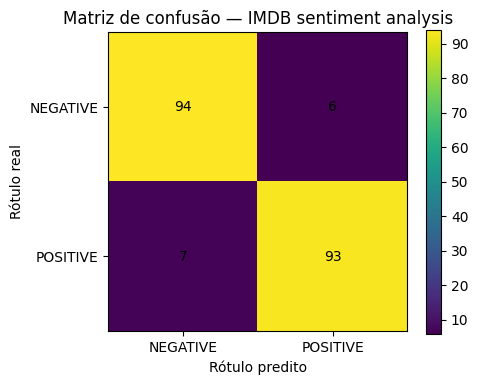

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Rótulo predito")
ax.set_ylabel("Rótulo real")
ax.set_title("Matriz de confusão — IMDB sentiment analysis")

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, cm[row, col], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 10. Análise dos erros

A célula abaixo mostra alguns exemplos em que o pipeline errou. Esses casos são úteis para a conclusão, pois ajudam a interpretar possíveis limitações do modelo.

In [ ]:
df_errors = df_results.loc[~df_results["correct"]].copy()
df_errors = df_errors.sort_values("score", ascending=False)

print("Total de erros:", len(df_errors))

cols = ["file", "true_label", "pred_label", "score", "n_chars", "text"]
display(df_errors[cols].head(10))

# Exibição textual de até 3 erros para análise qualitativa
for idx, row in df_errors.head(3).iterrows():
    print("=" * 100)
    print("Arquivo:", row["file"])
    print("Real:", row["true_label"], "| Predito:", row["pred_label"], "| Score:", round(row["score"], 4))
    print(row["text"][:1500])

Total de erros: 13


,file,true_label,pred_label,score,n_chars,text
182,4800_10.txt,POSITIVE,NEGATIVE,0.981443,1169,"Nazarin is some kind of saint,he wants to live..."
126,11776_10.txt,POSITIVE,NEGATIVE,0.929134,878,<br /><br />Fourteen of the funniest minutes o...
142,5672_7.txt,POSITIVE,NEGATIVE,0.917838,2592,**SPOILERS** Looking for a little more excitem...
125,7838_4.txt,NEGATIVE,POSITIVE,0.907033,940,Jean Claude Van Damme's movie career seems to ...
61,709_4.txt,NEGATIVE,POSITIVE,0.860271,1973,I just watched Atoll K-Laurel and Hardy's last...
181,2372_3.txt,NEGATIVE,POSITIVE,0.838462,914,"This is a comedy version of ""Strangers on a Tr..."
175,8603_10.txt,POSITIVE,NEGATIVE,0.829122,637,"Black Rain is a superb film, but watch out for..."
147,1511_9.txt,POSITIVE,NEGATIVE,0.752147,2974,"""Cat In The Brain"" is a series of extremely vi..."
27,909_4.txt,NEGATIVE,POSITIVE,0.649451,995,The story starts off in the home of a little g...
15,9957_10.txt,POSITIVE,NEGATIVE,0.609308,1593,There were at least a half dozen silent-film v...


Arquivo: 4800_10.txt
Real: POSITIVE | Predito: NEGATIVE | Score: 0.9814
Nazarin is some kind of saint,he wants to live in life exactly how Christ taught man to do.But it's too late:now the Catholic Church is between the hands of a wealthy bourgeoisie,the bishops live in luxury and don't give a damn about the poor and the sick.That's why our hero can't follow the way his hierarchy asks him to follow.So he divests himself of everything,and on his way to purity,he's joined by some kind of Mary Magdelene and a woman who's attracted by him sexually (the scene between this girl and her fiancé is telling).In Spain (it was the late fifties),they thought Nazarin was a Christian movie!Knowing Luis Bunuel,it was downright incongruous:all his work is anticlerical to a fault.Comparing Nazarin and his "holy women" to Jesus is a nonsense.On Nazarin's way,only brambles and couch grass grow.His attempt at helping working men on the road is a failure,he's chased out as a strike-breaker.All his words amo

## 11. Demonstração curta: por trás do pipeline

Esta seção reproduz, em escala pequena, a ideia apresentada no material do Hugging Face: o pipeline faz tokenização, passa os tensores pelo modelo e aplica pós-processamento para chegar ao rótulo final.

Aqui a demonstração usa apenas duas resenhas da própria amostra.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT).to(TORCH_DEVICE)
model.eval()

sample_texts = df_eval["text"].head(2).tolist()

inputs = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt",
).to(TORCH_DEVICE)

with torch.no_grad():
    logits = model(**inputs).logits
    probabilities = torch.nn.functional.softmax(logits, dim=-1)

id2label = model.config.id2label

manual_rows = []
for i in range(len(sample_texts)):
    probs = probabilities[i].detach().cpu().numpy()
    pred_id = int(np.argmax(probs))
    manual_rows.append({
        "texto": sample_texts[i][:200] + "...",
        "logits": logits[i].detach().cpu().numpy().round(4).tolist(),
        "probabilidades": probs.round(4).tolist(),
        "pred_id": pred_id,
        "pred_label": id2label[pred_id],
    })

display(pd.DataFrame(manual_rows))
print("Mapeamento id2label:", id2label)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,texto,logits,probabilidades,pred_id,pred_label
0,A rather lame teen slasher from Brisbane. Whil...,"[2.0859999656677246, -2.5364999771118164]","[0.9902999997138977, 0.009700000286102295]",0,NEGATIVE
1,"Mediocre at best. Slow, but probably more ente...","[1.1517000198364258, -1.5505000352859497]","[0.9372000098228455, 0.06279999762773514]",0,NEGATIVE


Mapeamento id2label: {0: 'NEGATIVE', 1: 'POSITIVE'}


## 12. Exportação dos resultados

Os arquivos gerados podem ser usados para conferir os resultados depois da execução.

In [ ]:
RESULTS_DIR = Path("resultados_trabalho04")
RESULTS_DIR.mkdir(exist_ok=True)

df_results.to_csv(RESULTS_DIR / "resultados_sentiment_imdb.csv", index=False)
df_report.to_csv(RESULTS_DIR / "metricas_sentiment_imdb.csv")
df_cm.to_csv(RESULTS_DIR / "matriz_confusao_sentiment_imdb.csv")
df_errors.to_csv(RESULTS_DIR / "erros_sentiment_imdb.csv", index=False)

print("Arquivos salvos em:", RESULTS_DIR.resolve())

Arquivos salvos em: /content/resultados_trabalho04


## 13. Conclusão

Neste trabalho, foi utilizado o `pipeline` da biblioteca `transformers`, do Hugging Face, para análise de sentimento na base IMDB. A execução foi realizada com uma amostra balanceada de **200 resenhas** do conjunto de teste, sendo **100 positivas** e **100 negativas**, utilizando o modelo **`lvwerra/distilbert-imdb`**.

O modelo obteve **acurácia de 93,50%**, com **187 acertos** e **13 erros**. Pela matriz de confusão, foram classificadas corretamente **94 resenhas negativas** e **93 resenhas positivas**; os erros foram **6 negativas classificadas como positivas** e **7 positivas classificadas como negativas**. As métricas por classe também ficaram equilibradas: para `NEGATIVE`, `precision = 0,9307`, `recall = 0,9400` e `f1-score = 0,9353`; para `POSITIVE`, `precision = 0,9394`, `recall = 0,9300` e `f1-score = 0,9347`.

Esse desempenho deve ser interpretado no contexto do experimento: o modelo utilizado é especializado na própria base IMDB, e a avaliação foi feita sobre uma amostra do conjunto de teste. Não há vazamento entre treino e teste, mas o resultado reflete um cenário *in-domain*, isto é, com textos do mesmo domínio usado no ajuste do modelo. Um teste complementar de generalização poderia ser feito com outro checkpoint, como `distilbert-base-uncased-finetuned-sst-2-english`, ajustado em uma base diferente da IMDB; nesse caso, seria razoável esperar acurácia menor ou comportamento diferente, por se tratar de um cenário menos especializado.


A análise de erros indicou que as principais falhas ocorreram em resenhas com sentimento misto, ironia, sarcasmo ou vocabulário negativo em textos cujo julgamento final era positivo. Mesmo com essas limitações, os resultados mostram que o uso de um Transformer pré-treinado por meio do `pipeline` permite realizar classificação de sentimentos de forma simples e eficiente, sem treinamento manual de uma rede neural. Também foi possível observar, de forma resumida, as etapas internas do processo: tokenização, processamento pelo modelo, geração dos `logits` e conversão das saídas em probabilidades e rótulos.
